# gpModel.py Testing

In [2]:
import gpModel
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def f1(x):
  x1, x2 = x
  return -(3*(x1 - 0.25)**2 + 5*(x2 - 0.75)**2 + 1)

def f2(x):
  x1, x2 = x
  return 14-2*(x1 - 0.5)**2 - 4*(x2 - 0.5)**2

x1_range = np.linspace(0, 1, 50)
x2_range = np.linspace(0, 1, 50)
X1, X2 = np.meshgrid(x1_range, x2_range)
X = np.vstack([X1.ravel(), X2.ravel()]).T

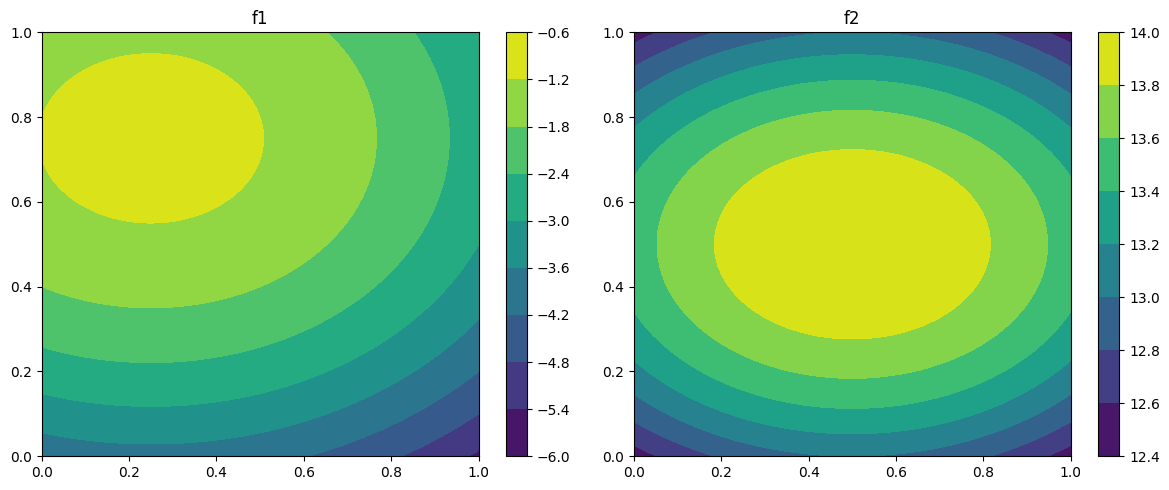

In [4]:
F1 = np.array([f1(x) for x in X]).reshape(X1.shape)
F2 = np.array([f2(x) for x in X]).reshape(X1.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
cs1 = ax1.contourf(X1, X2, F1)
cs2 = ax2.contourf(X1, X2, F2)
fig.colorbar(cs1, ax=ax1)
fig.colorbar(cs2, ax=ax2)
ax1.set_title("f1")
ax2.set_title("f2")
plt.tight_layout()
plt.show()

In [5]:
initial_designs = np.array([[0.25, 0.25], [0.75, 0.75], [0.375, 0.5], [0.125, 0.875]])
f1_values = np.array([f1(x) for x in initial_designs])
f2_values = np.array([f2(x) for x in initial_designs])

ndim = initial_designs.shape[1]

In [6]:
testf1 = gpModel.gp_model(initial_designs,f1_values,1,1,0.1,ndim,'SE')
testf2 = gpModel.gp_model(initial_designs,f2_values,1,1,0.1,ndim,'SE')

In [7]:
testf1.create_kernel()
testf2.create_kernel()

ConstantKernel(log_constant=-0.6931471805599453, ndim=2, axes=array([0, 1])) * ExpSquaredKernel(metric=Metric(1.0, ndim=2, axes=array([0, 1]), bounds=[(None, None)]), block=None)

In [8]:
testf1.create_gp()
testf2.create_gp()

In [9]:
mean1,sigma1 = testf1.predict_cov(X)
mean2,sigma2 = testf2.predict_cov(X)

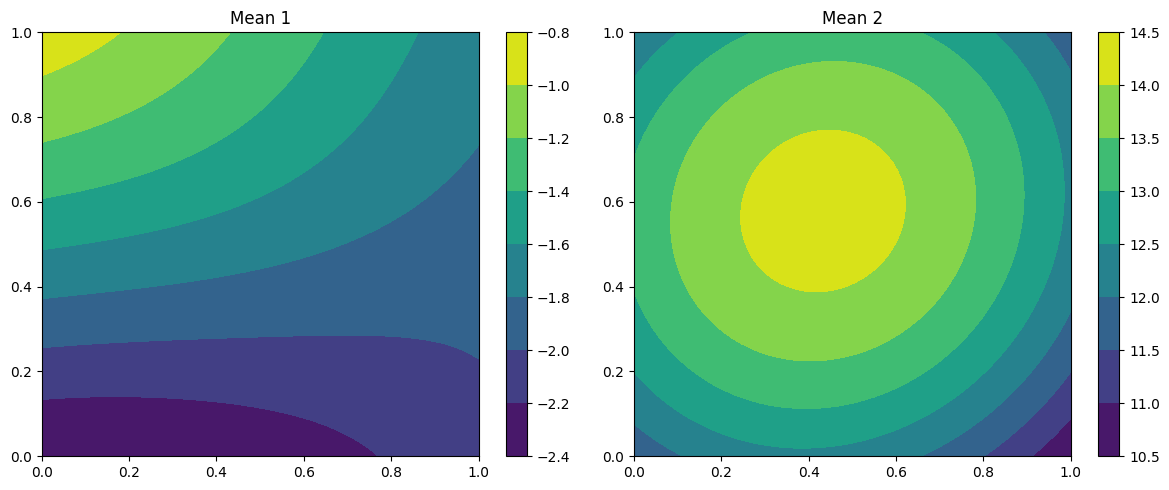

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
cs1 = ax1.contourf(X1, X2, mean1.reshape(X1.shape))
cs2 = ax2.contourf(X1, X2, mean2.reshape(X1.shape))
fig.colorbar(cs1, ax=ax1)
fig.colorbar(cs2, ax=ax2)
ax1.set_title("Mean 1")
ax2.set_title("Mean 2")
plt.tight_layout()
plt.show()

# main_BO.py Testing

In [11]:
import numpy as np
import pandas as pd
from pyDOE import *
from copy import deepcopy
from gpModel import gp_model
from acquisitionFunc import knowledge_gradient , expected_improvement
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from multiprocessing import Pool
import multiprocessing
from joblib import Parallel, delayed
import timeit
from multiobjective import EHVI, Pareto_finder, HV_Calc

In [12]:
def model(X):
    f1 = X[:,0]**2+np.exp(-X[:,1]/X[:,2])
    f2 = X[:,0]+X[:,2]
    f3 = X[:,1]/(1+X[:,2])
    f4 = np.log(X[:,3]+1)*X[:,0]
    f5 = X[:,1]*np.sin(X[:,3])+np.exp(X[:,0])
    f6 = np.sin(X[:,2])+np.cos(X[:,3])
    
    Y1 = (f1*f2+f2/f3+f4*f5+f6)/10
    Y2 = f2**2*f3+f4/f1+f5*f6
    return Y1,Y2

In [13]:
iteration=5
N_dim=4
lb1=0.01
ub1=1
lb2=0.01
ub2=1
lb3=0.01
ub3=1
lb4=0.01
ub4=1
N_test=1000
N_test_final=1000

N_training=100
reps = 2
N_obj=2
goal = np.ones([1,N_obj]) ## maximizing all objectives
ref=np.zeros([1,N_obj]) ## reference point

In [14]:
hv_curr=np.zeros([reps,iteration+1])

In [15]:
import time

In [19]:
for j in range(reps):
    pd.DataFrame(np.array(j).reshape(1,1)).to_csv("current_rep.csv", header=None, index=None)
    x_init = lhs(N_dim,N_training)*0.99+0.01
    y_init1,y_init2 = model(x_init)
    sf1=19**2 ### variance of the GP where no obsevation exists
    sn1=np.ones([N_training])*0.01
    l1=np.array([0.15,0.15,0.15,0.15])
    GPR1=gp_model(x_init, y_init1.reshape(x_init.shape[0]), l1, sf1, sn1, N_dim, 'SE' , mean=0)

    sf2=30**2 ### variance of the GP where no obsevation exists
    sn2=np.ones([N_training])*0.01
    l2=np.array([0.15,0.15,0.15,0.15])
    GPR2=gp_model(x_init, y_init2.reshape(x_init.shape[0]), l2, sf2, sn2, N_dim, 'SE' , mean=0)

    y=np.concatenate((y_init1.reshape(-1,1),y_init2.reshape(-1,1)),axis=1)
    train_y=y
    start = time.time()
    y_pareto_curr,index=Pareto_finder(train_y,goal)
    end = time.time()
    print('Pareto front calculation time:')
    print(end-start)
    start = time.time()
    hv_curr[j,0] = (HV_Calc(goal,ref,y_pareto_curr))[0]
    end = time.time()
    print('Hypervolume calculation time:')
    print(end-start)

    itr=0
    while itr<iteration:
        itr=itr+1
        
        x_test=lhs(N_dim,N_test)*0.99+0.01
        y1,var1=GPR1.predict_var(x_test)
        sig1=abs(var1)**0.5
        y2,var2=GPR2.predict_var(x_test)
        sig2=abs(var2)**0.5
        
        y=np.concatenate((y1.reshape(-1,1),y2.reshape(-1,1)),axis=1)
        sig=np.concatenate((sig1.reshape(-1,1),sig2.reshape(-1,1)),axis=1)
        
        n_jobs=multiprocessing.cpu_count()
        def calc(ii):
            e = EHVI(y[ii].reshape(1,-1),sig[ii].reshape(1,-1),goal,ref,y_pareto_curr)
            return e

        Ehvi=Parallel(n_jobs)(delayed(calc)(np.array([jj])) for jj in range(N_test))
        
        ### neutral acquisition function
        Ehvi=np.array(Ehvi)
        
        x_star=np.argmax(Ehvi)
        
        x_query=np.array(x_test[x_star]) ### here are the suggested parameters for this iteration
        # y_query=pd.DataFrame(pd.read_csv('/scratch/user/danialkh26/AnkitBO/error.csv', header=None)).to_numpy() # read error
        y_query1,y_query2=model(x_query.reshape(1,N_dim))
        
        GPR1.update(x_query.reshape(1,N_dim), y_query1.reshape(1), np.mean(sn1).reshape(1)) ## add the new data to the model
        GPR2.update(x_query.reshape(1,N_dim), y_query2.reshape(1), np.mean(sn2).reshape(1)) ## add the new data to the model

        train_y=np.concatenate((GPR1.ytrain().reshape(-1,1),GPR2.ytrain().reshape(-1,1)),axis=1)
        y_pareto_curr,index=Pareto_finder(train_y,goal)
        hv_curr[j,itr] = (HV_Calc(goal,ref,y_pareto_curr))[0]

Pareto front calculation time:
0.038800954818725586
Hypervolume calculation time:
0.0034079551696777344
Pareto front calculation time:
0.029537677764892578
Hypervolume calculation time:
0.0013818740844726562


In [22]:
y_pareto_curr

array([[ 2.06353276,  5.38695807],
       [ 0.83715251,  6.33302773],
       [ 2.45265085,  4.5039041 ],
       [11.9670169 ,  4.21757224]])

In [24]:
pareto_prime=np.zeros([1,2])
pareto_prime

array([[0., 0.]])

In [25]:
temp = np.max([y_pareto_curr[0,:],y_pareto_curr[1,:]],axis=0)
temp

array([2.06353276, 6.33302773])

In [26]:
pareto_prime = np.append(pareto_prime,[temp],axis=0)
pareto_prime

array([[0.        , 0.        ],
       [2.06353276, 6.33302773]])

In [9]:
Y=np.array(hv_curr)
YY=np.mean(Y,axis=0)
SS=np.std(Y,axis=0)
pd.DataFrame(hv_curr).to_csv("hv_curr_rand.csv", header=None, index=None)
pd.DataFrame(YY).to_csv("hv_average_rand.csv", header=None, index=None)
pd.DataFrame(SS).to_csv("hv_stdv_rand.csv", header=None, index=None)

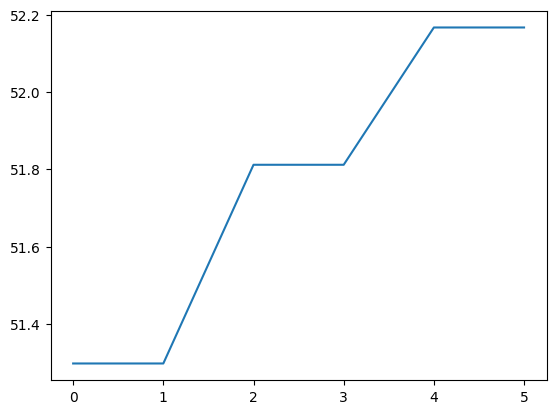

In [10]:
plt.plot(YY)

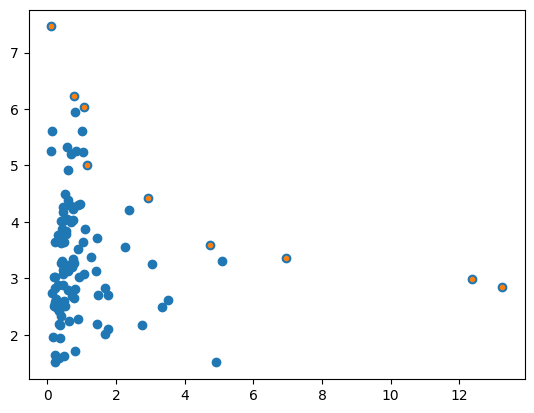

In [18]:
plt.plot(GPR1.ytrain(),GPR2.ytrain(),'o')
plt.plot(y_pareto_curr[:,0],y_pareto_curr[:,1], 'o', markersize=3)

# BoTorch

In [19]:
import botorch
import torch

In [20]:
tkwargs = {
    "dtype": torch.float32,
    "device": torch.device("mps" if torch.mps.is_available() else "cpu"),
}

In [21]:
ty = torch.from_numpy(train_y)
reft = torch.from_numpy(ref[0])

tygpu = ty.to(**tkwargs)
reftgpu = reft.to(**tkwargs)

In [22]:
start = time.time()
typar = ty[botorch.utils.multi_objective.pareto.is_non_dominated(ty)]
end = time.time()
print('Pareto front calculation time:')
print(end-start)

start = time.time()
hvt = botorch.utils.multi_objective.hypervolume.Hypervolume(reft).compute(typar)
end = time.time()
print('Hypervolume calculation time:')
print(end-start)

Pareto front calculation time:
0.018841981887817383
Hypervolume calculation time:
0.012732982635498047


In [23]:
hvt

47.57292243545249

In [24]:
start = time.time()
typargpu = tygpu[botorch.utils.multi_objective.pareto.is_non_dominated(tygpu)]
end = time.time()
print('Pareto front calculation time:')
print(end-start)

start = time.time()
hvtgpu = botorch.utils.multi_objective.hypervolume.Hypervolume(reftgpu).compute(typargpu)
end = time.time()
print('Hypervolume calculation time:')
print(end-start)

Pareto front calculation time:
0.2058119773864746
Hypervolume calculation time:
0.07553720474243164


In [25]:
hvtgpu

47.57292175292969